In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [3]:
df = df.replace(-999, np.nan)

In [4]:
df["Country"] = "Nigeria"

In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [6]:
df["Month"] = df["DATE"].dt.month

In [7]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [8]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M"]

z = df[cols].apply(zscore)
outliers = (abs(z) > 3)

outliers.sum()

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
dtype: int64

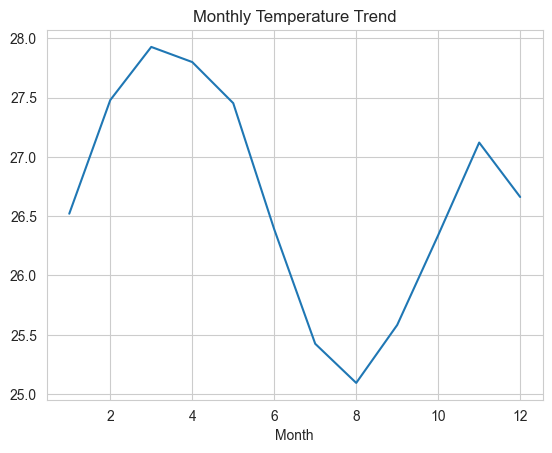

In [9]:
df.groupby("Month")["T2M"].mean().plot()
plt.title("Monthly Temperature Trend")
plt.show()

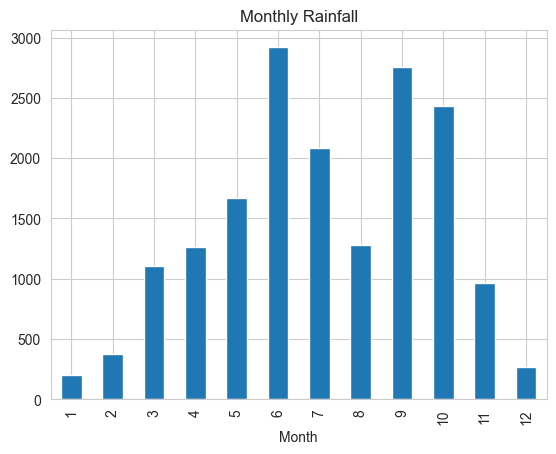

In [10]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

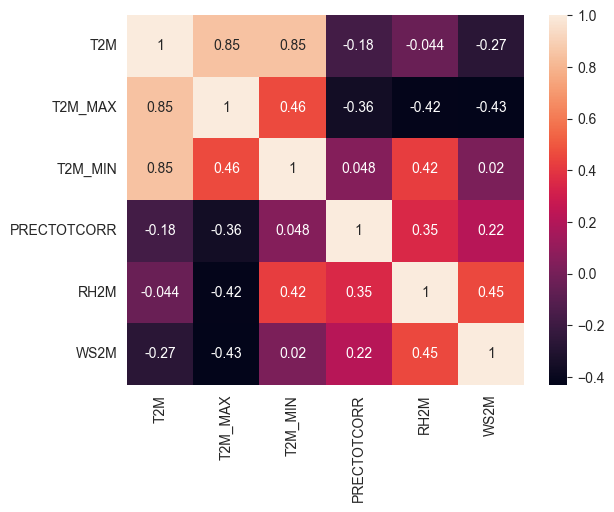

In [11]:
sns.heatmap(df[cols].corr(), annot=True)
plt.show()

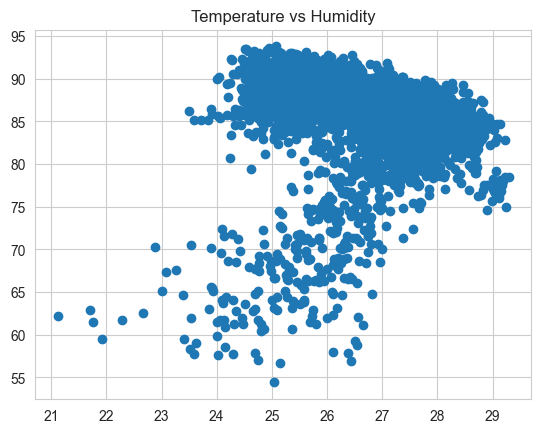

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.show()

In [13]:
df.to_csv("data/nigeria_clean.csv", index=False)

# nigera Climate Data EDA

This notebook explores climate patterns in nigeria using NASA dataset data.  
